# The second case: which payment rows in the feed should not be there, and what should the platform lead fix first?

**Week 2, Tuesday · The second case, in pairs · Kalpa's warehouse, both quarters.**

> **The client asks.** "Before I repair the payments feed, tell me which rows in it should not be
> there: payments with no order behind them, and payments the gateway posted twice. Both quarters,
> with the dates, the methods and the rupees at stake, and tell me what to fix first."
>
> The data platform lead, Kalpa Retail

**Who needs the answer.** The platform lead owns the warehouse and the feed that fills it, and
Finance must know whether any customer was charged twice. A feed fix aimed at the wrong
integration costs weeks and leaves the fault in place; a repeat deleted from the warehouse removes
the evidence Finance needs.

**The questions on the way.**
1. Is every payment row in the feed accounted for?
2. Which payments match no order?
3. Which instalments were posted more than once, in either quarter?
4. Is there a pattern the gateway team can act on?

**What you already have.** Anand's question started from the orders, because it was about every
booked order; this one starts from the payments, because it is about every row the feed holds, which
is the fact chapter 1 said would change the join. A retry is the same order and instalment posted
twice, and chapter 4 found the orders side of it for Q2. The warehouse's `payments` table holds 1,428
rows across both quarters.

**How this solution works.** Every letter is filled in and the notebook runs cold from the top, with
every check passing; under each step, a line says why the other letters fail. The empty cells stay
empty here too, since the lists and figures they print are what the case asks you to find: run them
yourself.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
from decimal import Decimal

conn = kit.connect()
conn.autocommit = True


def run(query, params=None):
    """Run a query on this notebook's one connection and return its rows as dictionaries."""
    return kit.sql(query, params, conn=conn)


def one(query, params=None):
    row = run(query, params)[0]
    return next(iter(row.values()))


def show(rows, caption="", money=()):
    """Rows as the kit's table; columns named in money print as rupees."""
    if not rows:
        return kit.table(["result"], [["no rows"]], caption)
    heads = list(rows[0])
    body = [[("NULL" if r[h] is None else kit.rupees(r[h]) if h in money else
              (f"{int(r[h]):,}" if isinstance(r[h], Decimal) and r[h] == r[h].to_integral_value() else str(r[h])))
             for h in heads] for r in rows]
    kit.table(heads, body, caption)


def crore(v):
    return f"{v:.2f}"

print("payments holds", one("SELECT count(*) FROM payments"), "rows.")

payments holds 1428 rows.


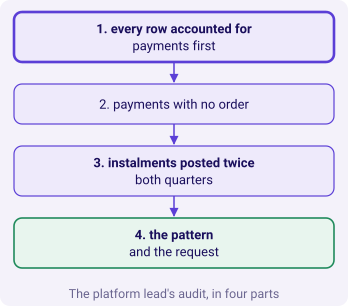

In [2]:
kit.vflow(["1. every row accounted for\npayments first", "2. payments with no order",
           "3. instalments posted twice\nboth quarters", "4. the pattern\nand the request"],
          kinds=["known", "plain", "plain", "good"], title="The platform lead's audit, in four parts")

## Part 1. Is every payment row in the feed accounted for?

Each payment row belongs to a Q1 order, a Q2 order or no order at all, and the three counts must add
to the table. At work, this is the first query any audit of a feed runs: before explaining any row,
prove that none was lost.

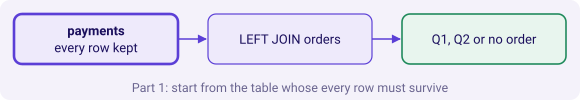

In [3]:
# TODO 1. Which join accounts for every payment row the feed holds?
#   a) orders o LEFT JOIN payments p ON p.order_id = o.order_id
#   b) orders o JOIN payments p ON p.order_id = o.order_id
#   c) payments p LEFT JOIN orders o ON o.order_id = p.order_id
#   d) payments p JOIN orders o ON o.order_id = p.order_id AND o.quarter IN ('Q1', 'Q2')
options_1 = {'a': 'orders o LEFT JOIN payments p ON p.order_id = o.order_id', 'b': 'orders o JOIN payments p ON p.order_id = o.order_id', 'c': 'payments p LEFT JOIN orders o ON o.order_id = p.order_id', 'd': "payments p JOIN orders o ON o.order_id = p.order_id AND o.quarter IN ('Q1', 'Q2')"}
choice_1 = 'c'

homes = run(f"""
SELECT coalesce(o.quarter, 'no order') AS home, count(p.payment_id) AS payment_rows
FROM {options_1[choice_1]}
GROUP BY coalesce(o.quarter, 'no order')
ORDER BY home""")
kit.flow(["payments\nevery row kept", "LEFT JOIN orders", "Q1, Q2 or no order"],
         kinds=["known", "plain", "good"], title="Part 1: start from the table whose every row must survive")

In [4]:
total_rows = one("SELECT count(*) FROM payments")
kit.check("the homes add to every row in the payments table", sum(r["payment_rows"] for r in homes) == total_rows,
          f"{total_rows:,} rows")
kit.check("every home is a quarter or no order", {r["home"] for r in homes} <= {"Q1", "Q2", "no order"})

**Why the other letters fail.** The key is c. a starts from orders, so a payment with no order never appears and an unpaid order adds a row the feed does not hold; b and d keep only payments that match an order.

**Your turn.** Show the three homes and their counts:

```python
show(homes, "Part 1: where each payment row belongs")
```

## Part 2. Which payments match no order?

The suspense list holds the payments whose order id is not in the orders table, with their ids,
dates, methods and amounts. At work these are held in a suspense account until someone finds the
order, or learns that the payment was never Kalpa's.

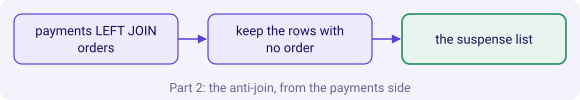

In [5]:
# TODO 2. Which condition keeps only the payments that match no order?
#   a) p.order_id IS NULL
#   b) o.order_id IS NULL
#   c) o.quarter NOT IN ('Q1', 'Q2')
#   d) p.amount > 0 AND o.amount IS NULL AND o.quarter = 'Q2'
options_2 = {'a': 'p.order_id IS NULL', 'b': 'o.order_id IS NULL', 'c': "o.quarter NOT IN ('Q1', 'Q2')", 'd': "p.amount > 0 AND o.amount IS NULL AND o.quarter = 'Q2'"}
choice_2 = 'b'

orphans = run(f"""
SELECT p.payment_id, p.order_id AS paid_for, p.paid_date, p.method, p.amount
FROM payments p
LEFT JOIN orders o ON o.order_id = p.order_id
WHERE {options_2[choice_2]}
ORDER BY p.payment_id""")
kit.flow(["payments LEFT JOIN orders", "keep the rows with no order", "the suspense list"],
         kinds=["plain", "plain", "good"], title="Part 2: the anti-join, from the payments side")

In [6]:
no_order = next((r["payment_rows"] for r in homes if r["home"] == "no order"), 0)
in_orders = one("SELECT count(*) FROM orders WHERE order_id = ANY(%s)", ([r["paid_for"] for r in orphans],))
kit.check("the list holds exactly the rows Part 1 found on no order", len(orphans) == no_order, "count unprinted")
kit.check("none of the listed order ids exists in the orders table", in_orders == 0)

**Why the other letters fail.** The key is b. a tests the payment's own order id, which the table never leaves empty; c is unknown for a NULL quarter, so it keeps nothing; d adds a Q2 test that no unmatched row can pass.

**Your turn.** Show the list and its total, and look at the dates and methods together:

```python
show(orphans, "Part 2: payments that match no order", money=["amount"])
print(len(orphans), "payments,", kit.rupees(sum(r["amount"] for r in orphans)))
```

## Part 3. Which instalments were posted more than once, in either quarter?

Every order and instalment the feed posted more than once goes on the retry list, with the order's
quarter beside it. At work the platform lead fixes the whole feed, which spans both quarters, so
this list covers everything the feed holds.

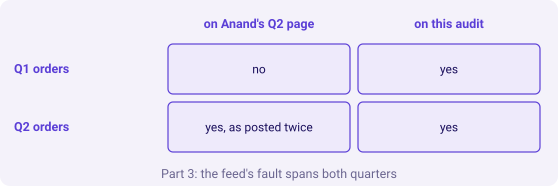

In [7]:
# TODO 3. Which rows should the retry list cover for the platform lead?
#   a) Q2 orders only, the quarter Anand asked about
#   b) Q1 orders only, since Q2 is already on Anand's page
#   c) payments made from 1 July only, whatever order they pay
#   d) both quarters, all the feed holds
options_3 = {
    "a": "WHERE o.quarter = 'Q2'",
    "b": "WHERE o.quarter = 'Q1'",
    "c": "WHERE p.paid_date >= '2026-07-01'",
    "d": "",
}
choice_3 = 'd'

retries = run(f"""
SELECT p.order_id, o.quarter, p.instalment_no, min(p.method) AS method, min(p.paid_date) AS paid_date,
       count(*) AS times_posted, sum(p.amount) - max(p.amount) AS posted_twice
FROM payments p
JOIN orders o ON o.order_id = p.order_id
{options_3[choice_3]}
GROUP BY p.order_id, o.quarter, p.instalment_no
HAVING count(*) > 1
ORDER BY o.quarter, p.order_id""")
kit.matrix(["Q1 orders", "Q2 orders"], ["on Anand's Q2 page", "on this audit"],
           [["no", "yes"], ["yes, as posted twice", "yes"]], title="Part 3: the feed's fault spans both quarters")

In [8]:
posted_matched = one("SELECT sum(p.amount) FROM payments p JOIN orders o ON o.order_id = p.order_id")
collected_matched = one("""SELECT sum(amount) FROM (SELECT p.order_id, p.instalment_no, max(p.amount) AS amount
    FROM payments p JOIN orders o ON o.order_id = p.order_id GROUP BY p.order_id, p.instalment_no) i""")
kit.check("the list's surplus equals posted less collected across the whole matched feed",
          sum(r["posted_twice"] for r in retries) == posted_matched - collected_matched, "equal, figures unprinted")
kit.check("every row on the list was posted more than once", all(r["times_posted"] > 1 for r in retries))

**Why the other letters fail.** The key is d. a and b split one fault across two reports and leave the platform lead half of it; c cuts by payment date, which is not how the feed files a retry.

**Your turn.** Show the list, and its count and surplus by quarter:

```python
show(retries, "Part 3: instalments posted more than once", money=["posted_twice"])
for q in ("Q1", "Q2"):
    rows = [r for r in retries if r["quarter"] == q]
    print(q, len(rows), kit.rupees(sum(r["posted_twice"] for r in rows)))
```

## Part 4. Is there a pattern the gateway team can act on?

The gateway team fixes one integration at a time, so the list has to say which one. At work, a fix
request that names the integration, the instalment and the date range gets scheduled; one that says
"the feed double-posts" does not.

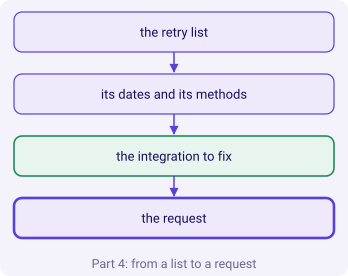

In [9]:
# TODO 4. Which dates tell the gateway team when the retries happened?
#   a) the first and last paid_date on the retry list
#   b) the first and last day of the quarters the orders belong to
#   c) the first and last paid_date of every payment in the feed
#   d) the paid_date of the first retry, since the rest repeat it
from datetime import date
retry_dates = [r["paid_date"] for r in retries]
options_4 = {
    "a": (min(retry_dates), max(retry_dates)),
    "b": (date(2026, 4, 1), date(2026, 9, 30)),
    "c": (one("SELECT min(paid_date) FROM payments"), one("SELECT max(paid_date) FROM payments")),
    "d": (min(retry_dates), min(retry_dates)),
}
choice_4 = 'a'
window = options_4[choice_4]

pattern = run("""
SELECT method, count(*) AS instalments, sum(extra) AS posted_twice
FROM (SELECT p.order_id, p.instalment_no, min(p.method) AS method, sum(p.amount) - max(p.amount) AS extra
      FROM payments p JOIN orders o ON o.order_id = p.order_id
      GROUP BY p.order_id, p.instalment_no HAVING count(*) > 1) r
GROUP BY method
ORDER BY method""")
kit.vflow(["the retry list", "its dates and its methods", "the integration to fix", "the request"],
          kinds=["plain", "plain", "good", "known"], title="Part 4: from a list to a request")

In [10]:
kit.check("every retry falls inside the window, and the window starts and ends on a retry",
          all(window[0] <= d <= window[1] for d in retry_dates) and window[0] in retry_dates and window[1] in retry_dates,
          "window unprinted")
kit.check("the method breakdown adds back to the whole retry list", sum(r["instalments"] for r in pattern) == len(retries)
          and sum(r["posted_twice"] for r in pattern) == sum(r["posted_twice"] for r in retries), "equal, figures unprinted")

**Why the other letters fail.** The key is a. b and c describe the quarters and the feed, so the window they give starts and ends on days with no retry; d assumes every retry happened on one day, which the list does not show.

**Your turn.** Show the window and the retries by payment method, then write your request to the
platform lead under it:

```python
print("from", window[0], "to", window[1])
show(pattern, "Part 4: the retries by payment method", money=["posted_twice"])
```

> "The feed holds ___ payments that match no order, Rs ___, all on ___ by ___: please hold them in
> suspense and trace them. It also holds ___ instalments posted twice, Rs ___ across both quarters,
> every one of them ___ instalment ___: please fix that integration so a retry cannot post twice,
> and keep the raw rows until Finance has checked with the bank whether any customer was charged
> twice."

## What do you post?

Post one line: your four TODO letters in order, no spaces, then your request to the platform lead.

```
Post exactly this shape: xxxx
```

In [11]:
kit.check_summary()